In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [2]:
df = pd.read_csv("owid-co2-data.csv")

In [3]:
df.head()

,iso_code,country,year,co2,consumption_co2,co2_growth_prct,co2_growth_abs,trade_co2,co2_per_capita,consumption_co2_per_capita,...,ghg_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
0,AFG,Afghanistan,1949,0.015,NaN,NaN,NaN,NaN,0.002,NaN,...,NaN,NaN,NaN,NaN,NaN,7624058.0,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,1950,0.084,NaN,475.0,0.070,NaN,0.011,NaN,...,NaN,NaN,NaN,NaN,NaN,7752117.0,9.421400e+09,NaN,NaN,NaN
2,AFG,Afghanistan,1951,0.092,NaN,8.7,0.007,NaN,0.012,NaN,...,NaN,NaN,NaN,NaN,NaN,7840151.0,9.692280e+09,NaN,NaN,NaN
3,AFG,Afghanistan,1952,0.092,NaN,0.0,0.000,NaN,0.012,NaN,...,NaN,NaN,NaN,NaN,NaN,7935996.0,1.001732e+10,NaN,NaN,NaN
4,AFG,Afghanistan,1953,0.106,NaN,16.0,0.015,NaN,0.013,NaN,...,NaN,NaN,NaN,NaN,NaN,8039684.0,1.063052e+10,NaN,NaN,NaN


In [4]:
df.tail()

,iso_code,country,year,co2,consumption_co2,co2_growth_prct,co2_growth_abs,trade_co2,co2_per_capita,consumption_co2_per_capita,...,ghg_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
25199,ZWE,Zimbabwe,2016,10.738,12.153,-12.17,-1.488,1.415,0.765,0.866,...,4.703,11.92,0.85,6.55,0.467,14030338.0,2.096179e+10,47.5,3385.574,1.889
25200,ZWE,Zimbabwe,2017,9.582,11.248,-10.77,-1.156,1.666,0.673,0.790,...,NaN,NaN,NaN,NaN,NaN,14236599.0,2.194784e+10,NaN,NaN,NaN
25201,ZWE,Zimbabwe,2018,11.854,13.163,23.72,2.273,1.308,0.821,0.912,...,NaN,NaN,NaN,NaN,NaN,14438812.0,2.271535e+10,NaN,NaN,NaN
25202,ZWE,Zimbabwe,2019,10.949,12.422,-7.64,-0.905,1.473,0.748,0.848,...,NaN,NaN,NaN,NaN,NaN,14645473.0,NaN,NaN,NaN,NaN
25203,ZWE,Zimbabwe,2020,10.531,NaN,-3.82,-0.418,NaN,0.709,NaN,...,NaN,NaN,NaN,NaN,NaN,14862927.0,NaN,NaN,NaN,NaN


In [5]:
df.shape

(25204, 58)

In [6]:
df.columns

Index(['iso_code', 'country', 'year', 'co2', 'consumption_co2',
       'co2_growth_prct', 'co2_growth_abs', 'trade_co2', 'co2_per_capita',
       'consumption_co2_per_capita', 'share_global_co2', 'cumulative_co2',
       'share_global_cumulative_co2', 'co2_per_gdp', 'consumption_co2_per_gdp',
       'co2_per_unit_energy', 'coal_co2', 'cement_co2', 'flaring_co2',
       'gas_co2', 'oil_co2', 'other_industry_co2', 'cement_co2_per_capita',
       'coal_co2_per_capita', 'flaring_co2_per_capita', 'gas_co2_per_capita',
       'oil_co2_per_capita', 'other_co2_per_capita', 'trade_co2_share',
       'share_global_cement_co2', 'share_global_coal_co2',
       'share_global_flaring_co2', 'share_global_gas_co2',
       'share_global_oil_co2', 'share_global_other_co2',
       'cumulative_cement_co2', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_oil_co2',
       'cumulative_other_co2', 'share_global_cumulative_cement_co2',
       'share_global_cumulative_c

In [7]:
df.dtypes

,0
iso_code,object
country,object
year,int64
co2,float64
consumption_co2,float64
co2_growth_prct,float64
co2_growth_abs,float64
trade_co2,float64
co2_per_capita,float64
consumption_co2_per_capita,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25204 entries, 0 to 25203
Data columns (total 58 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   iso_code                             21948 non-null  object 
 1   country                              25204 non-null  object 
 2   year                                 25204 non-null  int64  
 3   co2                                  23949 non-null  float64
 4   consumption_co2                      3976 non-null   float64
 5   co2_growth_prct                      24931 non-null  float64
 6   co2_growth_abs                       23585 non-null  float64
 7   trade_co2                            3976 non-null   float64
 8   co2_per_capita                       23307 non-null  float64
 9   consumption_co2_per_capita           3976 non-null   float64
 10  share_global_co2                     23949 non-null  float64
 11  cumulative_co2              

In [9]:
df.describe()

,year,co2,consumption_co2,co2_growth_prct,co2_growth_abs,trade_co2,co2_per_capita,consumption_co2_per_capita,share_global_co2,cumulative_co2,...,ghg_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
count,25204.000000,23949.000000,3976.000000,24931.000000,23585.000000,3976.000000,23307.000000,3976.000000,23949.000000,2.394900e+04,...,5155.000000,5211.000000,5157.000000,5211.000000,5157.000000,2.287800e+04,1.353800e+04,8690.000000,8681.000000,6803.000000
mean,1953.225797,267.861942,916.755170,21.098600,5.146889,-2.415624,4.170811,6.567721,4.983979,1.035710e+04,...,8.099506,82.253370,2.046923,29.308135,0.606690,7.072322e+07,2.877088e+11,1569.083895,25568.487454,1.850291
std,53.791369,1521.680894,3373.348275,702.565991,55.259760,182.444942,14.912201,6.927957,17.704994,6.120603e+04,...,9.387477,566.702756,3.534126,199.291118,0.844671,3.795858e+08,2.180094e+12,9066.102799,33319.956208,1.575161
min,1750.000000,0.000000,0.197000,-99.640000,-1895.244000,-1657.998000,0.000000,0.055000,0.000000,0.000000e+00,...,-50.487000,0.000000,0.000000,0.000000,0.000000,1.490000e+03,5.543200e+07,0.000000,0.000000,0.050000
25%,1925.000000,0.528000,10.319750,-0.450000,-0.011000,-0.892500,0.253000,1.240250,0.010000,6.992000e+00,...,2.514000,2.150000,0.715000,0.535000,0.228000,1.291899e+06,9.828867e+09,6.997000,3270.369000,0.856000
50%,1967.000000,4.857000,57.091000,3.350000,0.059000,1.953000,1.250000,4.359500,0.060000,9.131800e+01,...,5.474000,9.030000,1.111000,3.590000,0.384000,4.880320e+06,3.037019e+10,61.404500,13701.318000,1.407000
75%,1995.000000,42.818000,276.378750,10.460000,1.103000,9.700500,4.657500,9.848500,0.600000,1.147514e+03,...,10.299000,31.055000,1.690000,10.570000,0.607000,1.759622e+07,1.268944e+11,352.884500,35493.775000,2.351000
max,2020.000000,36702.503000,36702.503000,102318.510000,1736.258000,1028.487000,748.639000,57.792000,100.000000,1.696524e+06,...,86.991000,8660.010000,39.812000,3054.000000,8.239000,7.794799e+09,1.136302e+14,162194.290000,317582.498000,13.493000


# Dataset Understanding

The OWID CO₂ dataset contains information about carbon dioxide emissions, energy consumption, greenhouse gas emissions, population, GDP, and other environmental indicators for different countries and years.

The dataset includes both numerical and categorical features. The target variable for this analysis is **co2**, which represents carbon dioxide emissions. Since the target variable is continuous, Linear Regression is an appropriate machine learning algorithm for prediction.

In [10]:
df.isnull().sum()

,0
iso_code,3256
country,0
year,0
co2,1255
consumption_co2,21228
co2_growth_prct,273
co2_growth_abs,1619
trade_co2,21228
co2_per_capita,1897
consumption_co2_per_capita,21228


In [11]:
df.isnull().sum().sum()

np.int64(760695)

In [12]:
numeric_cols = df.select_dtypes(include=["number"]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [13]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df.isnull().sum()

,0
iso_code,0
country,0
year,0
co2,0
consumption_co2,0
co2_growth_prct,0
co2_growth_abs,0
trade_co2,0
co2_per_capita,0
consumption_co2_per_capita,0




Missing values were identified using the `isnull()` function. Numerical columns were filled using the mean because it preserves the average value of the data. Categorical columns were filled using the mode since it represents the most frequently occurring category. This preprocessing step ensures that the dataset is complete before training machine learning models.

In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.shape

(25204, 58)



Duplicate records were checked using the `duplicated()` function and removed using `drop_duplicates()`. Removing duplicate data helps improve data quality and prevents repeated observations from influencing the machine learning model.

In [19]:
df.corr(numeric_only=True)

,year,co2,consumption_co2,co2_growth_prct,co2_growth_abs,trade_co2,co2_per_capita,consumption_co2_per_capita,share_global_co2,cumulative_co2,...,ghg_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
year,1.000000,0.087825,-0.004839,-0.011317,0.021519,0.000613,0.096892,0.001565,-0.400973,0.097833,...,-0.002288,0.000487,-0.002860,0.000579,-0.003091,0.003453,0.043339,0.002164,0.005761,-0.019885
co2,0.087825,1.000000,0.909245,-0.004842,0.480573,-0.161096,0.034893,0.004937,0.374378,0.951637,...,0.010110,0.649875,-0.013426,0.653965,-0.009979,0.850589,0.410451,0.856005,0.054989,0.025560
consumption_co2,-0.004839,0.909245,1.000000,-0.000184,0.423026,-0.124282,0.004616,0.012145,0.292069,0.879508,...,-0.014807,0.702204,-0.013660,0.706792,-0.029249,0.790938,0.400357,0.874254,0.002550,0.015342
co2_growth_prct,-0.011317,-0.004842,-0.000184,1.000000,0.001166,-0.000170,0.012967,-0.000449,-0.007150,-0.004912,...,-0.000270,-0.000187,0.000125,-0.000175,0.000200,-0.003902,-0.002866,-0.000507,-0.001062,-0.000629
co2_growth_abs,0.021519,0.480573,0.423026,0.001166,1.000000,-0.253228,0.007248,-0.041955,0.220150,0.343705,...,-0.007752,0.308276,-0.012172,0.316246,-0.010265,0.488960,0.227394,0.397604,-0.001087,0.012127
trade_co2,0.000613,-0.161096,-0.124282,-0.000170,-0.253228,1.000000,0.007875,0.123503,-0.042007,0.031086,...,-0.000472,-0.040002,-0.015343,-0.030043,0.009211,-0.230210,-0.047067,-0.011858,0.045958,-0.048526
co2_per_capita,0.096892,0.034893,0.004616,0.012967,0.007248,0.007875,1.000000,0.176615,-0.001992,0.041661,...,0.119848,0.004093,0.044579,0.003496,0.012612,-0.012816,0.029754,0.021132,0.250089,0.111657
consumption_co2_per_capita,0.001565,0.004937,0.012145,-0.000449,-0.041955,0.123503,0.176615,1.000000,-0.001196,0.045601,...,0.441995,-0.019883,0.146494,-0.018655,0.074220,-0.061907,0.050400,0.024535,0.638657,0.212070
share_global_co2,-0.400973,0.374378,0.292069,-0.007150,0.220150,-0.042007,-0.001992,-0.001196,1.000000,0.338387,...,0.003166,0.194331,-0.003908,0.195188,-0.002730,0.446860,0.122193,0.282133,0.020186,0.012085
cumulative_co2,0.097833,0.951637,0.879508,-0.004912,0.343705,0.031086,0.041661,0.045601,0.338387,1.000000,...,0.017962,0.650320,-0.010935,0.653420,-0.006395,0.754601,0.424276,0.859373,0.075806,0.020683


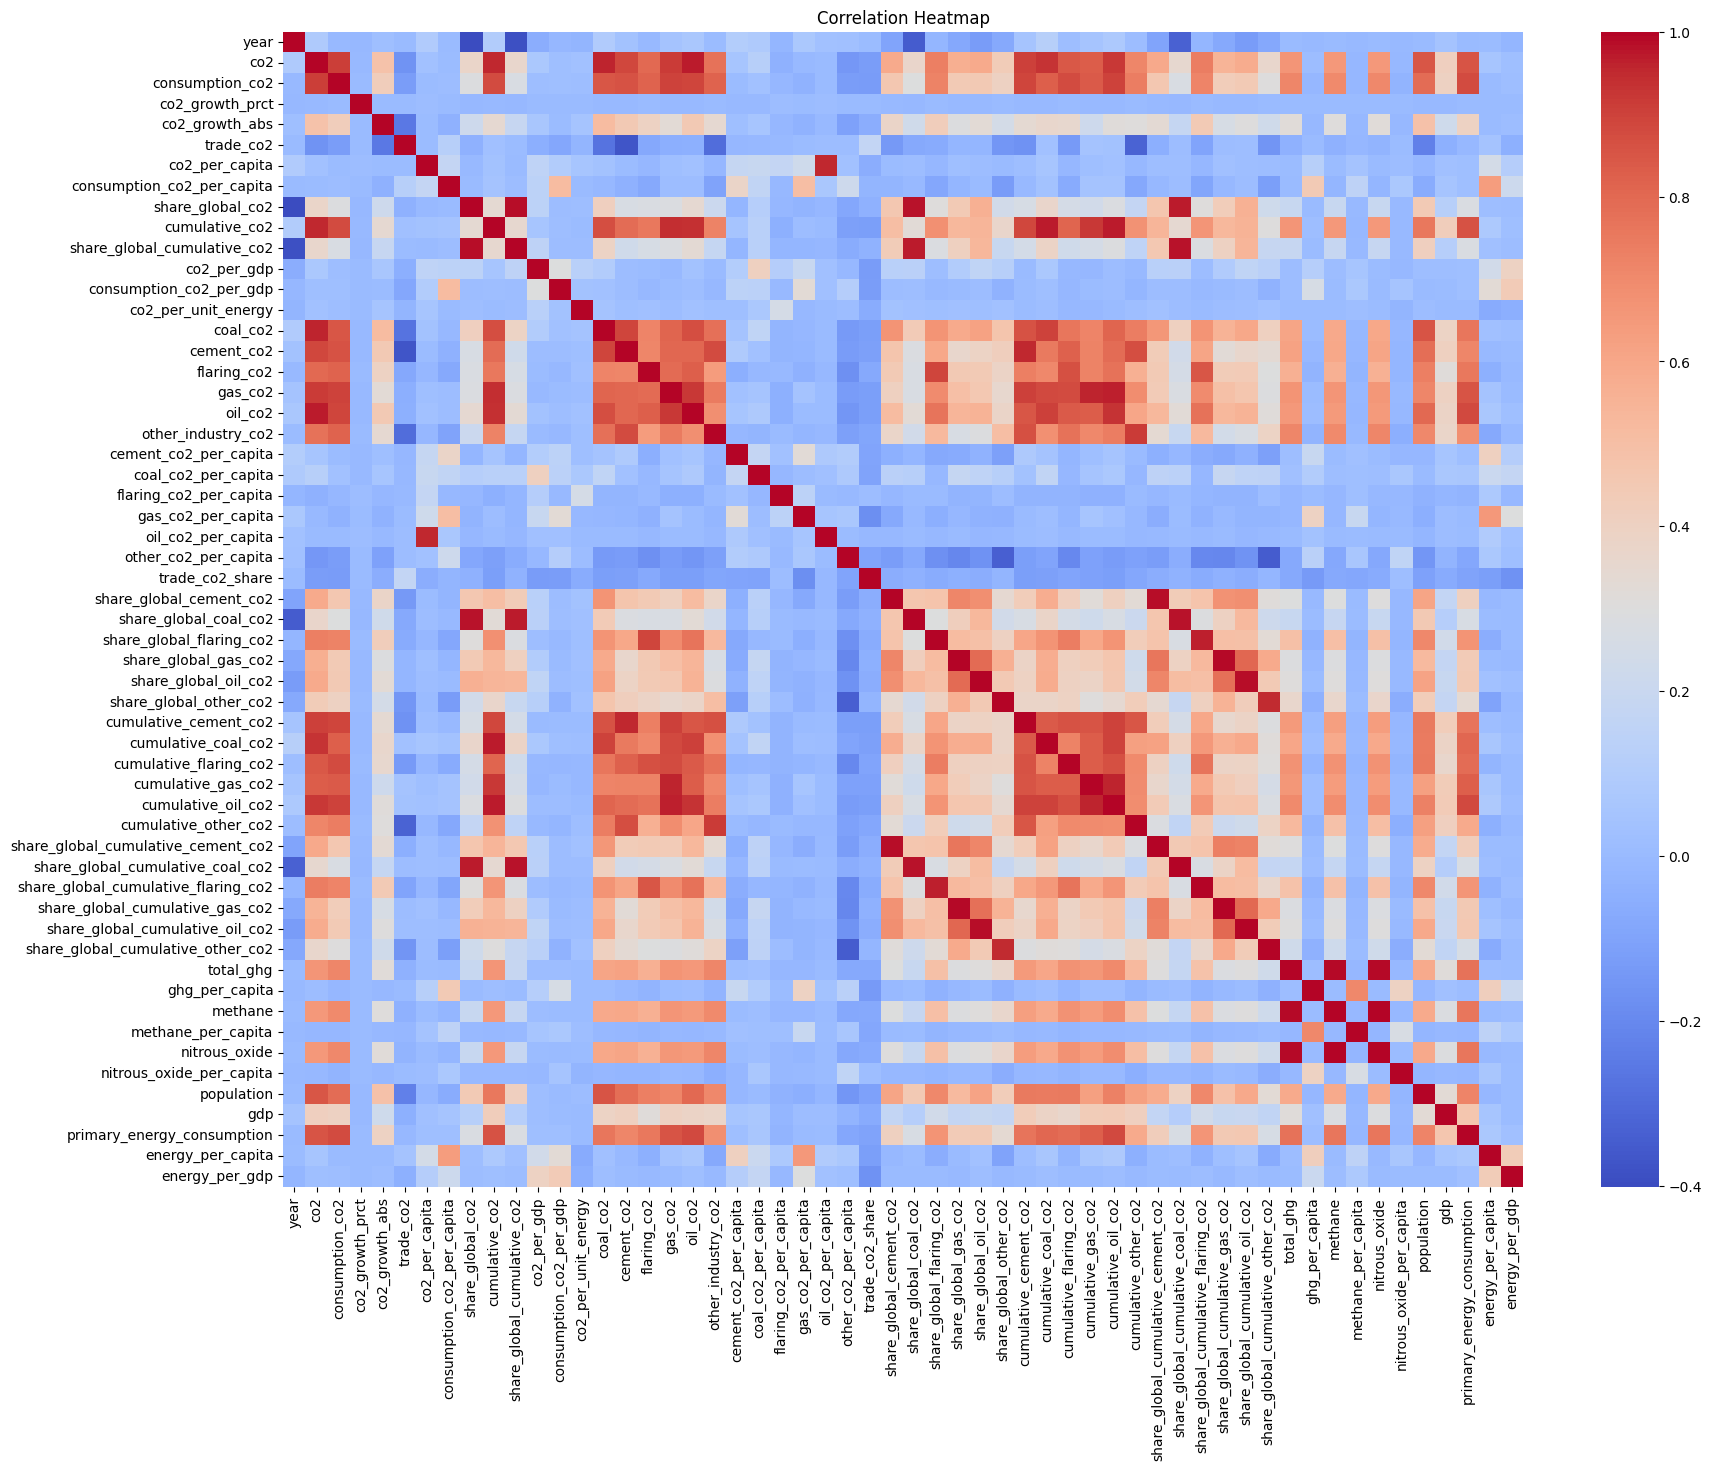

In [20]:
plt.figure(figsize=(20,15))

sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm',
            annot=False)

plt.title("Correlation Heatmap")
plt.show()



The heatmap shows the relationship between numerical variables. Positive correlation indicates that two variables increase together, while negative correlation indicates that one variable decreases as the other increases. Highly correlated features are useful for prediction.

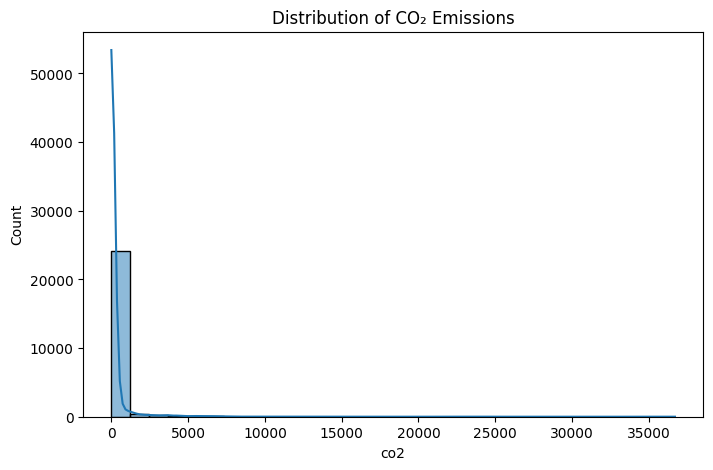

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['co2'], bins=30, kde=True)

plt.title("Distribution of CO₂ Emissions")
plt.show()

The histogram shows how CO₂ emissions are distributed across the dataset. Most observations are concentrated within a specific range, while a few countries have significantly higher emissions.

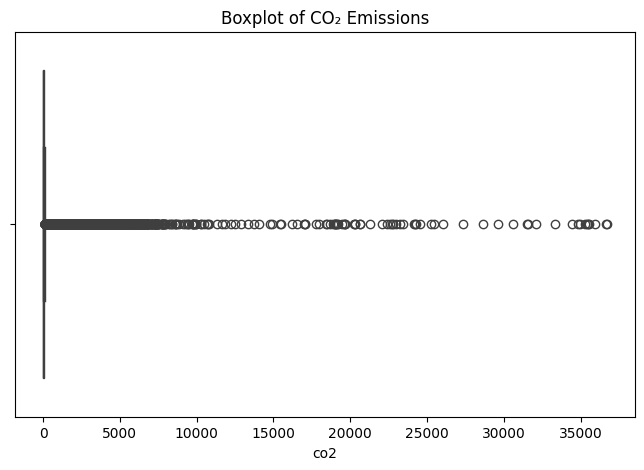

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['co2'])

plt.title("Boxplot of CO₂ Emissions")
plt.show()

The boxplot helps identify outliers in CO₂ emissions. Extreme values are expected because some countries emit much more CO₂ than others.

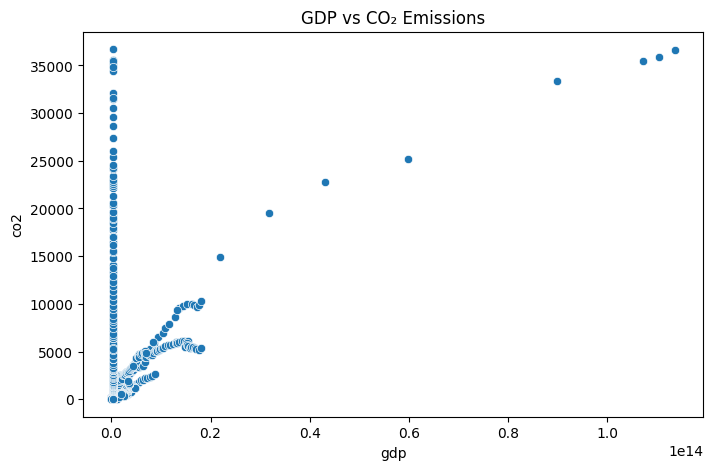

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x='gdp',
                y='co2')

plt.title("GDP vs CO₂ Emissions")
plt.show()

The scatter plot shows the relationship between GDP and CO₂ emissions. Countries with higher GDP generally tend to produce more CO₂ emissions.

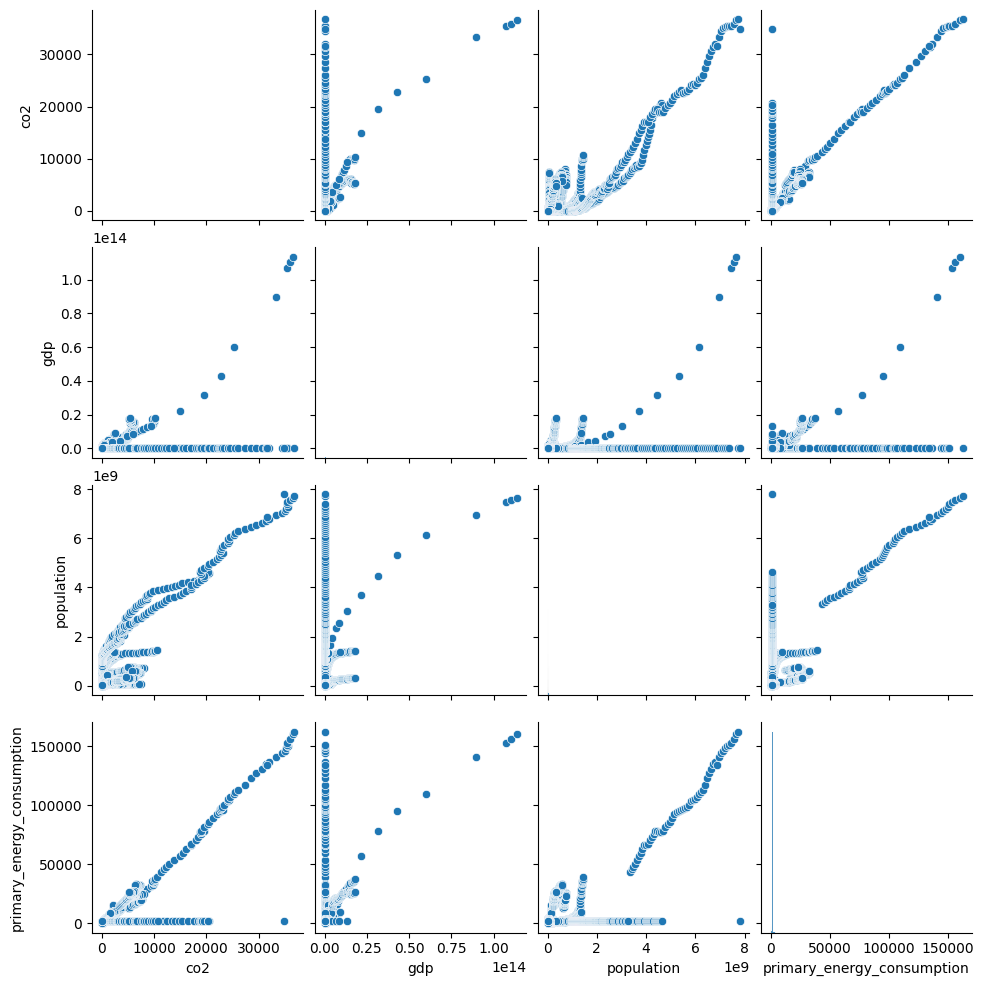

In [24]:
sns.pairplot(df[['co2',
                 'gdp',
                 'population',
                 'primary_energy_consumption']])

plt.show()

The pairplot visualizes relationships between selected numerical variables. It helps identify trends, correlations, and distributions among important environmental indicators.

In [26]:
df["Total_Fossil_CO2"] = (
    df["coal_co2"] +
    df["oil_co2"] +
    df["gas_co2"]
)

In [27]:
df[["coal_co2","oil_co2","gas_co2","Total_Fossil_CO2"]].head()

,coal_co2,oil_co2,gas_co2,Total_Fossil_CO2
0,0.015,106.254381,108.750774,215.020155
1,0.021,0.063000,108.750774,108.834774
2,0.026,0.066000,108.750774,108.842774
3,0.032,0.060000,108.750774,108.842774
4,0.038,0.068000,108.750774,108.856774




A new feature named **Total_Fossil_CO2** was created by combining coal, oil, and gas CO₂ emissions. This feature represents total emissions from major fossil fuels and may improve model performance.

In [28]:
df.select_dtypes(include='object').columns

Index(['iso_code', 'country'], dtype='object')

In [29]:
df = pd.get_dummies(df,
                    columns=['country','iso_code'],
                    drop_first=True)

Categorical variables were converted into numerical values using One-Hot Encoding. Machine learning algorithms require numerical input, so this transformation allows the model to process country and code information.

In [30]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

num_cols

Index(['year', 'co2', 'consumption_co2', 'co2_growth_prct', 'co2_growth_abs',
       'trade_co2', 'co2_per_capita', 'consumption_co2_per_capita',
       'share_global_co2', 'cumulative_co2', 'share_global_cumulative_co2',
       'co2_per_gdp', 'consumption_co2_per_gdp', 'co2_per_unit_energy',
       'coal_co2', 'cement_co2', 'flaring_co2', 'gas_co2', 'oil_co2',
       'other_industry_co2', 'cement_co2_per_capita', 'coal_co2_per_capita',
       'flaring_co2_per_capita', 'gas_co2_per_capita', 'oil_co2_per_capita',
       'other_co2_per_capita', 'trade_co2_share', 'share_global_cement_co2',
       'share_global_coal_co2', 'share_global_flaring_co2',
       'share_global_gas_co2', 'share_global_oil_co2',
       'share_global_other_co2', 'cumulative_cement_co2',
       'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2',
       'cumulative_oil_co2', 'cumulative_other_co2',
       'share_global_cumulative_cement_co2',
       'share_global_cumulative_coal_co2',
       'share

In [31]:
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [32]:
df.head()

,year,co2,consumption_co2,co2_growth_prct,co2_growth_abs,trade_co2,co2_per_capita,consumption_co2_per_capita,share_global_co2,cumulative_co2,...,iso_code_VCT,iso_code_VEN,iso_code_VGB,iso_code_VNM,iso_code_VUT,iso_code_WSM,iso_code_YEM,iso_code_ZAF,iso_code_ZMB,iso_code_ZWE
0,-0.078561,-0.180577,-2.545871e-16,5.084482e-18,-1.661565e-17,2.451684e-17,-0.290718,3.228206e-16,-0.288789,-0.173598,...,False,False,False,False,False,False,False,False,False,False
1,-0.059970,-0.180531,-2.545871e-16,6.496030e-01,-9.497618e-02,2.451684e-17,-0.290090,3.228206e-16,-0.288789,-0.173596,...,False,False,False,False,False,False,False,False,False,False
2,-0.041379,-0.180525,-2.545871e-16,-1.774431e-02,-9.615476e-02,2.451684e-17,-0.290020,3.228206e-16,-0.288789,-0.173595,...,False,False,False,False,False,False,False,False,False,False
3,-0.022788,-0.180525,-2.545871e-16,-3.019535e-02,-9.628571e-02,2.451684e-17,-0.290020,3.228206e-16,-0.288789,-0.173593,...,False,False,False,False,False,False,False,False,False,False
4,-0.004198,-0.180516,-2.545871e-16,-7.296884e-03,-9.600510e-02,2.451684e-17,-0.289950,3.228206e-16,-0.288789,-0.173591,...,False,False,False,False,False,False,False,False,False,False



StandardScaler was applied to numerical columns so that all features have a similar scale. This improves the performance of machine learning algorithms and prevents features with larger values from dominating the model.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25204 entries, 0 to 25203
Columns: 518 entries, year to iso_code_ZWE
dtypes: bool(461), float64(57)
memory usage: 22.0 MB


In [34]:
X = df.drop("co2", axis=1)

y = df["co2"]



The target variable selected for prediction is **co2**, which represents carbon dioxide emissions. All remaining columns are used as input features for the Linear Regression model.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [36]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (20163, 517)
Testing Features: (5041, 517)
Training Target: (20163,)
Testing Target: (5041,)


The dataset was divided into 80% training data and 20% testing data. The training data is used to train the model, while the testing data is used to evaluate its performance on unseen data.

In [37]:
lr_model = LinearRegression()

In [38]:
lr_model.fit(X_train, y_train)

LinearRegression()

The Linear Regression model was trained using the training dataset. During training, the model learned the relationship between the input features and the CO₂ emissions.

In [39]:
y_pred = lr_model.predict(X_test)

In [40]:
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

prediction_df.head(10)

,Actual,Predicted
14835,-0.178065,-0.178716
23581,-0.174276,-0.166031
9804,-0.110233,-0.110829
15571,-0.170939,-0.167436
13059,-0.173097,-0.170617
24437,-0.177065,-0.188883
13056,-0.175116,-0.175928
20475,-0.170750,-0.169518
1114,-0.168958,-0.166690
21529,-0.179536,-0.185608


In [41]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.002797230316454915
Mean Squared Error (MSE): 1.927634904135822e-05
Root Mean Squared Error (RMSE): 0.004390483918813303
R2 Score: 0.9999708988261442




- **MAE (Mean Absolute Error):** Measures the average difference between actual and predicted values. Lower values indicate better performance.
- **MSE (Mean Squared Error):** Penalizes larger prediction errors more heavily.
- **RMSE (Root Mean Squared Error):** Represents the prediction error in the same units as the target variable.
- **R² Score:** Indicates how well the model explains the variation in CO₂ emissions. A value closer to 1 indicates better performance.

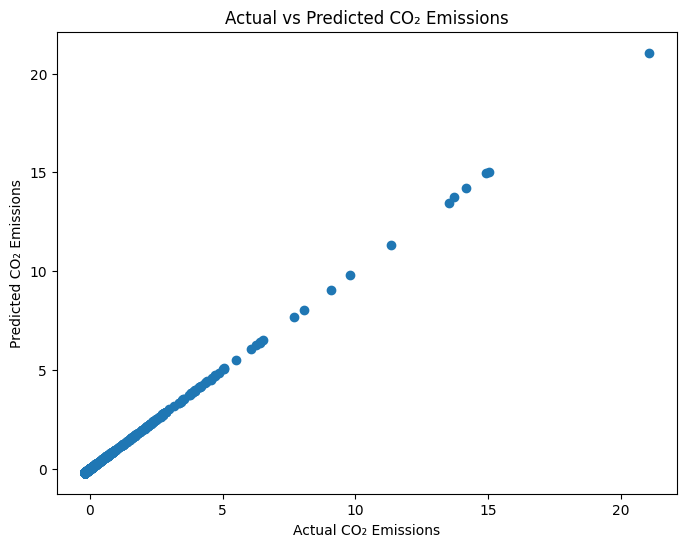

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")
plt.title("Actual vs Predicted CO₂ Emissions")

plt.show()

The scatter plot compares the actual CO₂ emission values with the predicted values. Points closer to an imaginary diagonal line indicate more accurate predictions.

In [43]:
joblib.dump(lr_model, "2026-07-11_LinearRegression.pkl")

['2026-07-11_LinearRegression.pkl']

In [44]:
import os

print(os.listdir())

['.config', '2026-07-11_LinearRegression.pkl', 'air_quality_health_impact_data.csv', 'owid-co2-data.csv', 'sample_data']




1. The OWID CO₂ dataset was used to predict carbon dioxide emissions.
2. Missing values were handled to improve data quality.
3. Duplicate records were removed to avoid repeated observations.
4. A new feature, **Total_Fossil_CO2**, was created using coal, oil, and gas emissions.
5. Categorical columns were converted into numerical format using One-Hot Encoding.
6. Numerical features were standardized using StandardScaler.
7. The dataset was split into training and testing sets using an 80:20 ratio.
8. Linear Regression was selected because the target variable (**co2**) is continuous.
9. The model was evaluated using MAE, MSE, RMSE, and R² Score.
10. The trained model was successfully saved as **2026-07-11_LinearRegression.pkl**.

In [46]:
df = pd.read_csv("air_quality_health_impact_data.csv")

In [47]:
df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


In [48]:
df.tail()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
5806,5807,171.112762,11.246387,197.984628,158.643107,17.743678,280.370909,37.359323,61.707640,4.097129,14,5,2,100.000000,4.0
5807,5808,490.691667,275.340762,55.774170,132.336871,29.334724,108.043492,34.532542,21.528555,6.682549,8,6,2,100.000000,3.0
5808,5809,314.841798,41.892699,184.708551,82.105823,68.334578,105.568503,22.975564,92.725625,2.889698,12,2,3,100.000000,1.0
5809,5810,208.080473,165.533785,199.177255,100.796385,87.586488,166.469537,36.090620,25.836286,10.722393,6,2,3,100.000000,4.0
5810,5811,83.269257,82.216262,119.968244,193.440691,79.849177,28.681885,18.239090,77.096194,16.410320,14,2,2,81.668298,0.0


In [49]:
df.shape

(5811, 15)

In [50]:
df.columns

Index(['RecordID', 'AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'Temperature',
       'Humidity', 'WindSpeed', 'RespiratoryCases', 'CardiovascularCases',
       'HospitalAdmissions', 'HealthImpactScore', 'HealthImpactClass'],
      dtype='object')

In [51]:
df.dtypes

,0
RecordID,int64
AQI,float64
PM10,float64
PM2_5,float64
NO2,float64
SO2,float64
O3,float64
Temperature,float64
Humidity,float64
WindSpeed,float64


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   float64
dtypes: float64(11), int64(4)
memory usage:

In [53]:
df.describe()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
count,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000
mean,2906.000000,248.438476,148.654997,100.223714,102.293445,49.456838,149.312431,14.975500,54.776853,9.989177,9.974187,4.988986,2.001033,93.785223,0.281191
std,1677.635538,144.777638,85.698500,58.096612,57.713175,28.530329,86.534240,14.483067,26.020786,5.776950,3.129234,2.216791,1.398794,13.318904,0.714075
min,1.000000,0.005817,0.015848,0.031549,0.009625,0.011023,0.001661,-9.990998,10.001506,0.002094,1.000000,0.000000,0.000000,22.448488,0.000000
25%,1453.500000,122.951293,75.374954,49.435171,53.538538,24.887264,73.999665,2.481500,31.995262,4.952343,8.000000,3.000000,1.000000,98.203057,0.000000
50%,2906.000000,249.127841,147.634997,100.506337,102.987736,49.530165,149.559871,14.942428,54.543904,10.051742,10.000000,5.000000,2.000000,100.000000,0.000000
75%,4358.500000,373.630668,222.436759,151.340260,151.658516,73.346617,223.380126,27.465374,77.641639,14.971840,12.000000,6.000000,3.000000,100.000000,0.000000
max,5811.000000,499.858837,299.901962,199.984965,199.980195,99.969561,299.936812,39.963434,99.997493,19.999139,23.000000,14.000000,12.000000,100.000000,4.000000




The Air Quality Health Impact dataset contains information about different air pollutants, weather conditions, and their effects on human health.

The target variable is **HealthImpactClass**, which represents different health impact categories. Since the target is categorical, Logistic Regression is an appropriate classification algorithm.

In [54]:
df.isnull().sum()

,0
RecordID,0
AQI,0
PM10,0
PM2_5,0
NO2,0
SO2,0
O3,0
Temperature,0
Humidity,0
WindSpeed,0


In [55]:
num_cols = df.select_dtypes(include=["number"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [56]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df.drop_duplicates(inplace=True)

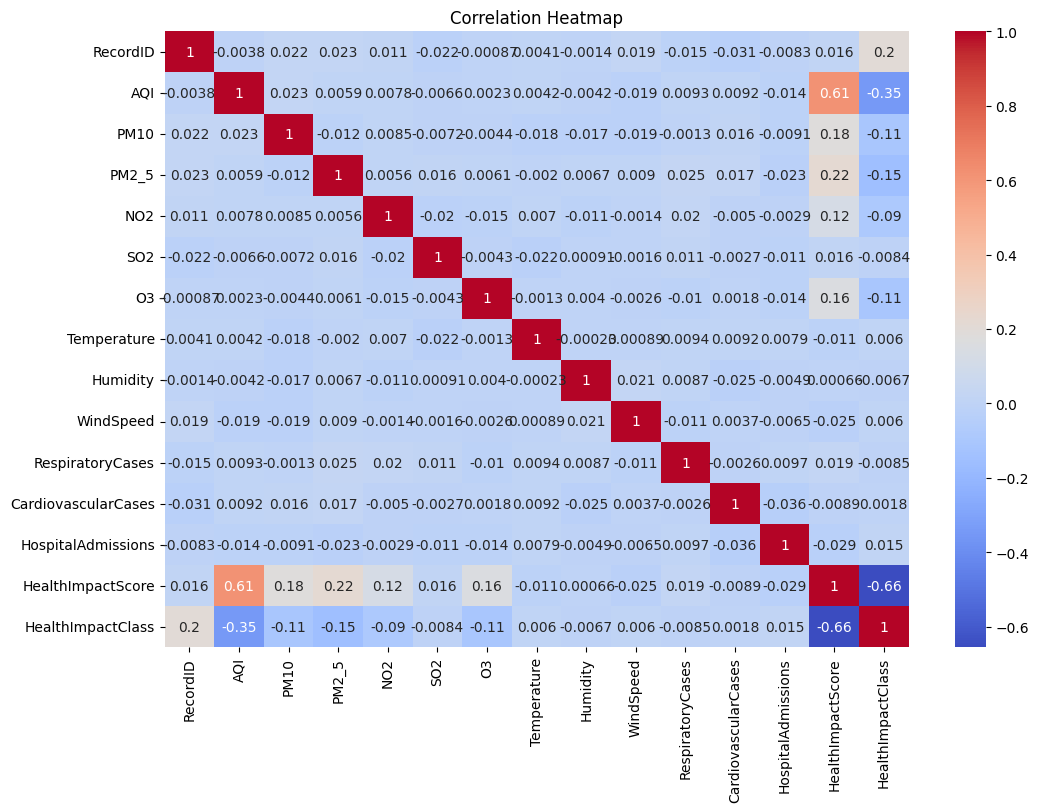

In [59]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

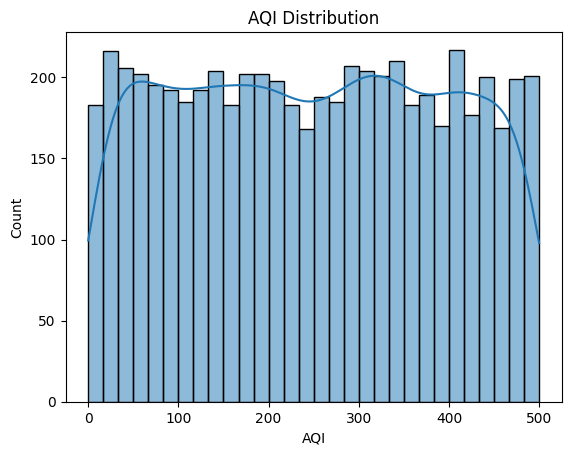

In [60]:
sns.histplot(df["AQI"], bins=30, kde=True)

plt.title("AQI Distribution")
plt.show()

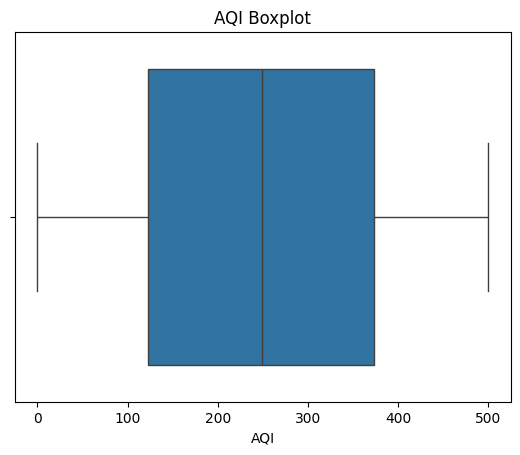

In [61]:
sns.boxplot(x=df["AQI"])

plt.title("AQI Boxplot")
plt.show()

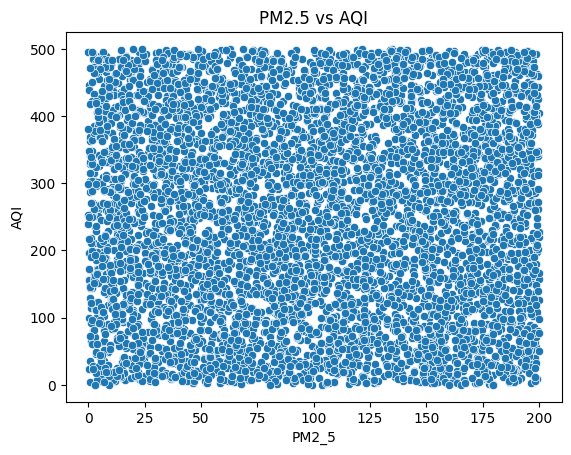

In [62]:
sns.scatterplot(data=df,
                x="PM2_5",
                y="AQI")

plt.title("PM2.5 vs AQI")
plt.show()

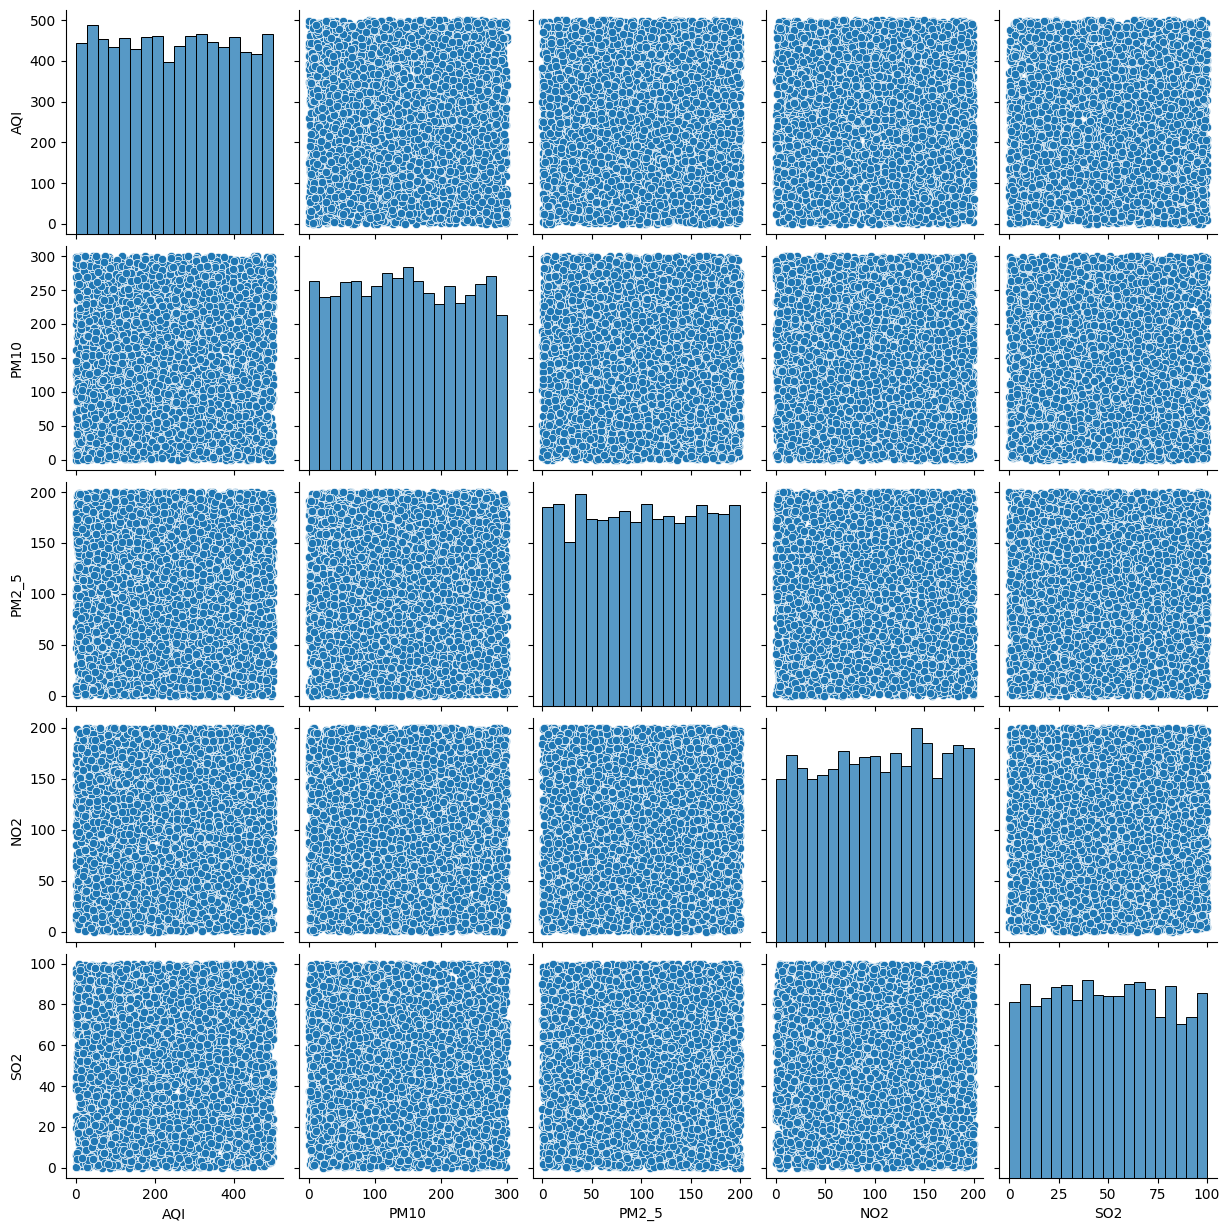

In [63]:
sns.pairplot(df[[
    "AQI",
    "PM10",
    "PM2_5",
    "NO2",
    "SO2"
]])

plt.show()

In [64]:
df["PollutionIndex"] = (
    df["PM10"] +
    df["PM2_5"] +
    df["NO2"] +
    df["SO2"] +
    df["O3"]
) / 5

In [65]:
df[["PM10","PM2_5","NO2","SO2","O3","PollutionIndex"]].head()

,PM10,PM2_5,NO2,SO2,O3,PollutionIndex
0,295.853039,13.038560,6.639263,66.161150,54.624280,87.263258
1,246.254703,9.984497,16.318326,90.499523,169.621728,106.535755
2,84.443191,23.111340,96.317811,17.875850,9.006794,46.150997
3,21.020609,14.273403,81.234403,48.323616,93.161033,51.602612
4,16.987667,152.111623,121.235461,90.866167,241.795138,124.599211




A new feature called **PollutionIndex** was created by averaging major air pollutants (PM10, PM2.5, NO2, SO2, and O3). This feature summarizes the overall pollution level and may improve the classification model.

In [66]:
le = LabelEncoder()

df["HealthImpactClass"] = le.fit_transform(df["HealthImpactClass"])

In [67]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [68]:
df = pd.get_dummies(df, drop_first=True)

In [69]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols] = scaler.fit_transform(df[num_cols])



StandardScaler was applied to numerical features so that all variables have similar ranges. Scaling helps Logistic Regression perform better and prevents variables with larger values from dominating the model.

In [70]:
X = df.drop("HealthImpactClass", axis=1)

y = df["HealthImpactClass"]

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [72]:
log_model = LogisticRegression(max_iter=1000)

In [73]:
log_model.fit(X_train, y_train)

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [76]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [77]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=["int64","float64"]).columns

num_cols = num_cols.drop("HealthImpactClass")

df[num_cols] = scaler.fit_transform(df[num_cols])

In [78]:
X = df.drop("HealthImpactClass", axis=1)

y = df["HealthImpactClass"]

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [80]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [81]:
df["HealthImpactClass"].head(10)

,HealthImpactClass
0,-0.393817
1,-0.393817
2,-0.393817
3,-0.393817
4,-0.393817
5,1.006717
6,1.006717
7,-0.393817
8,-0.393817
9,-0.393817


In [82]:
print(df["HealthImpactClass"].unique())

[-0.39381743  1.00671689  3.80778552  2.4072512   5.20831984]


In [83]:
print(df["HealthImpactClass"].dtype)

float64


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   float64
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   float64
 11  CardiovascularCases  5811 non-null   float64
 12  HospitalAdmissions   5811 non-null   float64
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   float64
 15  PollutionIndex       5811 non-null   f

In [85]:
df = pd.read_csv("air_quality_health_impact_data.csv")

In [86]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["HealthImpactClass"] = le.fit_transform(df["HealthImpactClass"])

In [87]:
print(df["HealthImpactClass"].unique())

[0 1 3 2 4]


In [88]:
X = df.drop("HealthImpactClass", axis=1)

y = df["HealthImpactClass"]

In [89]:
scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [91]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [92]:
y_pred = log_model.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9079965606190885


In [94]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       953
           1       0.70      0.79      0.74       124
           2       0.61      0.51      0.56        53
           3       0.00      0.00      0.00        20
           4       0.00      0.00      0.00        13

    accuracy                           0.91      1163
   macro avg       0.45      0.46      0.45      1163
weighted avg       0.88      0.91      0.90      1163



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[931  21   1   0   0]
 [ 16  98   8   2   0]
 [ 10  16  27   0   0]
 [ 10   2   8   0   0]
 [  8   4   0   1   0]]


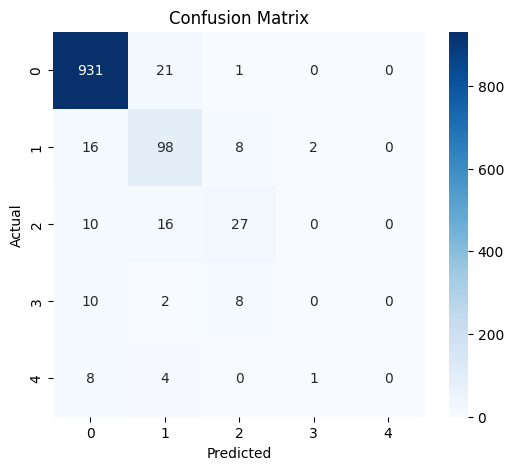

In [96]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [97]:
import joblib

joblib.dump(log_model, "2026-07-11_LogisticRegression.pkl")

['2026-07-11_LogisticRegression.pkl']

In [98]:
import os

print(os.listdir())

['.config', '2026-07-11_LinearRegression.pkl', 'air_quality_health_impact_data.csv', '2026-07-11_LogisticRegression.pkl', 'owid-co2-data.csv', 'sample_data']


# Final Insights

## Regression Model

- The OWID CO₂ dataset was used to predict carbon dioxide (CO₂) emissions using Linear Regression.
- Before training the model, missing values and duplicate records were handled to improve the quality of the dataset.
- A new feature called **Total_Fossil_CO2** was created by combining emissions from coal, oil, and gas to provide additional information for the model.
- Numerical features were standardized using StandardScaler so that all features were on a similar scale.
- The model was evaluated using MAE, MSE, RMSE, and R² Score to understand how accurately it predicts CO₂ emissions.

## Classification Model

- The Air Quality Health Impact dataset was used to classify different health impact categories using Logistic Regression.
- Missing values were handled, and the target column was encoded using LabelEncoder.
- Numerical features were scaled, while the target column was kept unchanged because classification models require class labels.
- The model was evaluated using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix to measure its performance.

## Conclusion

This task helped in understanding the complete machine learning workflow, starting from data preprocessing to model evaluation. Feature engineering, data scaling, visualization, and model building were performed successfully. Both the Linear Regression and Logistic Regression models were trained, evaluated, and saved as `.pkl` files for future use.